Hi there!

The objective of this code to figure out how many coils of what radii should you choose in order to have a 20mT magnetic field within 1 ppm variation in the region of the electron trap which is currently 1.75*2 m long and 0.33 m in radius

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

mu0 = 4e-7 * np.pi

In the next block we input number of coils, the spread of the whole magnet, radius of each coil, and number and radii of side coils if needed

The number of coils and the range is printed for confirmation

In [2]:
n_coils_main = 54
z_min, z_max = -3.8, 3.8
z_main, dz_main = np.linspace(z_min, z_max, n_coils_main, retstep=True)

R_main = 0.81      # m
B0 = 0.02          # Tesla (20 mT target)

# End rings on each
n_end_each_side = 0
R_end = 0.25       # m (50 cm internal diameter)


z_left  = z_min - dz_main * np.arange(n_end_each_side, 0, -1)
z_right = z_max + dz_main * np.arange(1, n_end_each_side + 1)

z_coils = np.concatenate([z_left, z_main, z_right])
R_coils = np.concatenate([
    np.full(n_end_each_side, R_end),
    np.full(n_coils_main, R_main),
    np.full(n_end_each_side, R_end),
])
n_coils = len(z_coils)

print("Total coils:", n_coils)
print("Coil z range:", z_coils[0], "to", z_coils[-1])

Total coils: 54
Coil z range: -3.8 to 3.8


Numerical value of a: 1551194.6106864945


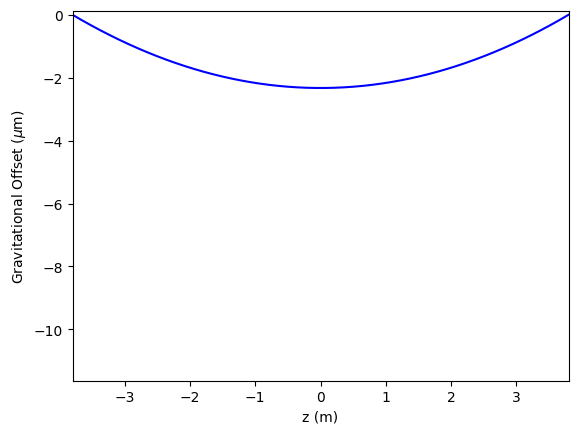

In [3]:
from numpy.typing import NDArray
from scipy.optimize import root_scalar
def make_offset(z: NDArray, l_scale: float, d: float) -> NDArray:
    """ Computes the catenary curve of length l_scale*d where d is the displacement when the ends are at equal heights. """
    if l_scale <= 1:
        raise ValueError("Length of material must be larger than displacement.")
    y_disp = np.zeros_like(z)

    a0 = 0.9
    x0 = d/(2*a0)


    def l_resid(x: float):
        return l_scale - np.sinh(x)/x
    # def false_pos_method(l: float, d: float, a1: float, a2: float):
    #     f1 = l_resid(l, d, a1)
    #     f2 = l_resid(l, d, a2)
    #     a3 = (f1*a2 - f2*a1)/(f1*f2)
    #     f3 = l_resid(l, d, a3)
    #     print(f"{a1}, {a2} yield {a3}")
    #     print(f"Residuals: {f1}, {f2} and {f3}")
    #     return
    # false_pos_method(l, d, a1, a2)
    sol = root_scalar(l_resid, method = 'secant', x0 = x0, rtol = 1e-10)
    x = sol.root
    a = d/(2*x)
    print(f"Numerical value of a: {a}")
    y_disp = a*(np.sinh((z + d/2)/(2*a))*np.sinh((z - d/2)/(2*a)))
    

    return y_disp

offset = make_offset(z_main, 1 + 1e-12, 2*max(z_main))
plt.plot(z_main, 1e6*offset, color = "b")
plt.ylim((5*min(offset)*1e6, abs(min(offset))/20*1e6))
plt.xlim((min(z_main), max(z_main)))
plt.xlabel("z (m)")
plt.ylabel(fr"Gravitational Offset ($\mu$m)")
plt.show()

Next cell is Chebyshev Nodes distribution. This is just the distribution of points where we want to force the uniformity. The Chebyshev points are not uniformly distributed points - the density of the points on the extreme is larger than in the center. This works because previous analysis shows that the uniformity requirement is not met at the extreme, so this distribution forces to make the field more uniform on the extremes because there are more "trim points" there

The math of the distribution is given in the block as well,

In [4]:
def chebyshev_nodes(n, a, b):
    # n Chebyshev nodes mapped to [a, b], returned sorted ascending.
    k = np.arange(1, n + 1)
    x = np.cos((2*k - 1) * np.pi / (2*n))
    z = 0.5*(a + b) + 0.5*(b - a)*x
    return np.sort(z)

next block defines the fit region, number of fit points, and the region of the fit points.

I have been using 1.75*2 m long and 0.33*2 m thick cylinder for this. This is what defines the electron trap region

In [5]:
# FIT region
fit_min, fit_max = -1.75, 1.75

n_fit_z = 3000
z_fit = chebyshev_nodes(n_fit_z, fit_min, fit_max)
r_fit = np.array([0.0, 0.1, 0.2, 0.330], dtype=float)

# PPM evaluation region
ppm_z_min, ppm_z_max = -1.75, 1.75
ppm_r_max = 0.33

n_ppm_z = 181
n_ppm_r = 61
z_ppm = chebyshev_nodes(n_ppm_z, ppm_z_min, ppm_z_max)
r_ppm = np.linspace(0.0, ppm_r_max, n_ppm_r)

print("Fit grid points:", len(z_fit) * len(r_fit))
print("PPM eval points:", len(z_ppm) * len(r_ppm))

Fit grid points: 12000
PPM eval points: 11041


In [6]:
# FIT region
fit_min, fit_max = -1.75, 1.75

n_fit_z = 3000
z_fit = chebyshev_nodes(n_fit_z, fit_min, fit_max)
r_fit = np.array([0.0, 0.1, 0.2, 0.330], dtype=float)

def φ_from_r(r: NDArray, c: float = 50) -> dict:

    φ_fit = [0]*len(r)
    for i in range(len(r)):
        n_azim = max(1, int(r[i]*c))
        dφ = 2*np.pi/n_azim
        φ_fit[i] = (np.array(np.arange(n_azim) + 0.5)) * dφ

    n_rφ = len(np.concatenate(φ_fit).ravel())

    φ_info = {
        "φ_list": φ_fit,    # List of points to sample, φ_list[i] corresponds with r[i]
        "n_rφ": n_rφ        # Number of points in r-φ plane
    }
    return φ_info

φ_data = φ_from_r(r_fit)
φ_fit = φ_data["φ_list"]
n_rφ = φ_data["n_rφ"]

# PPM evaluation region
ppm_z_min, ppm_z_max = -1.75, 1.75
ppm_r_max = 0.33

n_ppm_z = 181
n_ppm_r = 61
z_ppm = chebyshev_nodes(n_ppm_z, ppm_z_min, ppm_z_max)
r_ppm = np.linspace(0.0, ppm_r_max, n_ppm_r)


φ_from_r_ppm = φ_from_r(r_ppm, c = 250)
φ_ppm = φ_from_r_ppm["φ_list"]
n_rφ_ppm = φ_from_r_ppm["n_rφ"]



print("Fit grid points:", len(z_fit) * n_rφ)
print("PPM eval points:", len(z_ppm) * n_rφ_ppm)



Fit grid points: 96000
PPM eval points: 450871


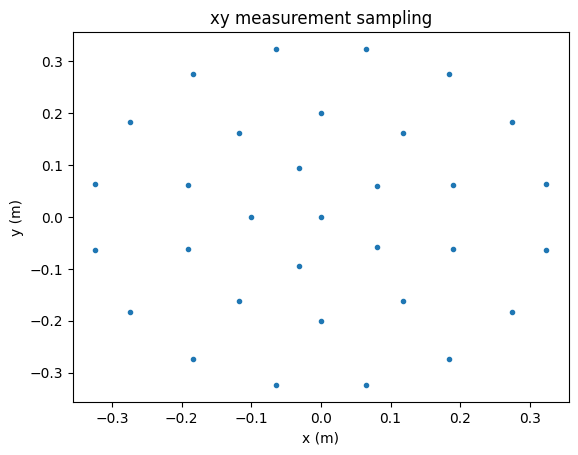

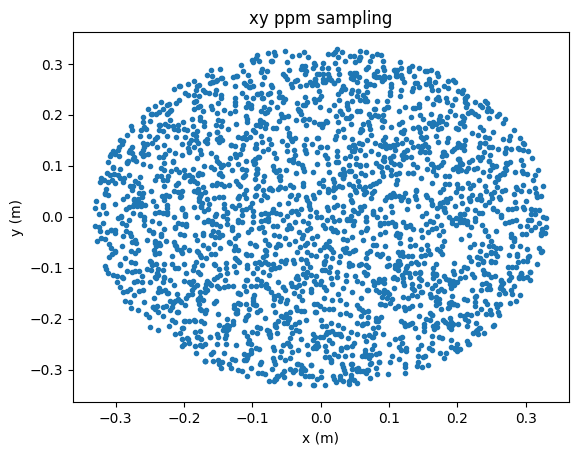

In [7]:
xy_list = np.empty((0, 2))
for i in range(len(r_fit)):
    rad = r_fit[i]
    for j in φ_fit[i]:
        xy_list = np.append(xy_list, np.array([[rad*np.cos(j), rad*np.sin(j)]]), axis = 0)

plt.plot(xy_list.transpose()[0], xy_list.transpose()[1], ".")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("xy measurement sampling")
plt.show()


xy_ppm = np.empty((0, 2))
for i in range(len(r_ppm)):
    rad = r_ppm[i]
    for j in φ_ppm[i]:
        rand_num = np.random.random() # Trying to determine whether it is better to leave organized or not
        xy_ppm = np.append(xy_ppm, np.array([[rad*np.cos(j+rand_num), rad*np.sin(j+rand_num)]]), axis = 0)


plt.plot(xy_ppm.transpose()[0], xy_ppm.transpose()[1], ".")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("xy ppm sampling")
plt.show()


next couple of blocks are just me plotting different things for testing and visualizaation

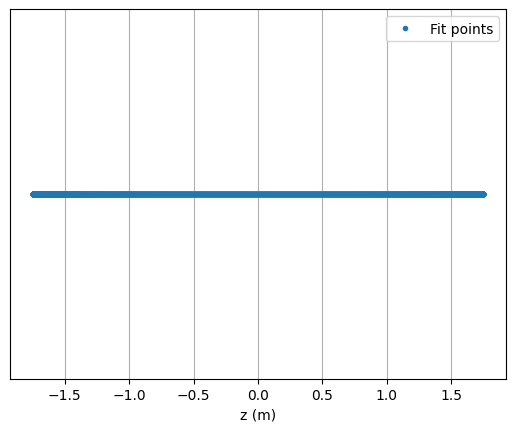

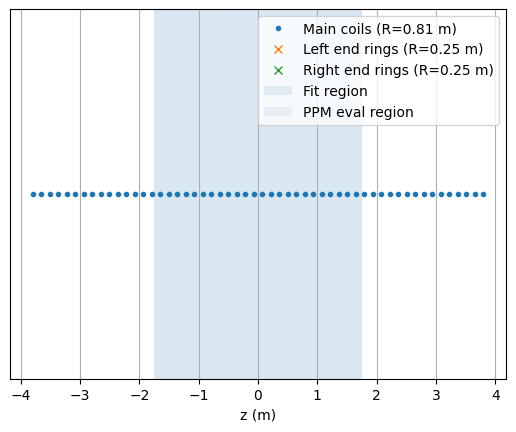

In [8]:
plt.figure()
plt.plot(z_fit, np.zeros_like(z_fit), ".", label="Fit points")
plt.xlabel("z (m)")
plt.yticks([])
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(z_main, np.zeros_like(z_main), ".", label="Main coils (R=0.81 m)")
plt.plot(z_left,  np.zeros_like(z_left),  "x", label="Left end rings (R=0.25 m)")
plt.plot(z_right, np.zeros_like(z_right), "x", label="Right end rings (R=0.25 m)")
plt.axvspan(fit_min, fit_max, alpha=0.10, label="Fit region")
plt.axvspan(ppm_z_min, ppm_z_max ,alpha=0.08, label="PPM eval region")
plt.xlabel("z (m)")
plt.yticks([])
plt.grid(True)
plt.legend()
plt.show()

In the next block I use Biot-Savart law to calculate magnetic field at any point. This is done by segmenting a loop with nseg. nseg = 720 for example

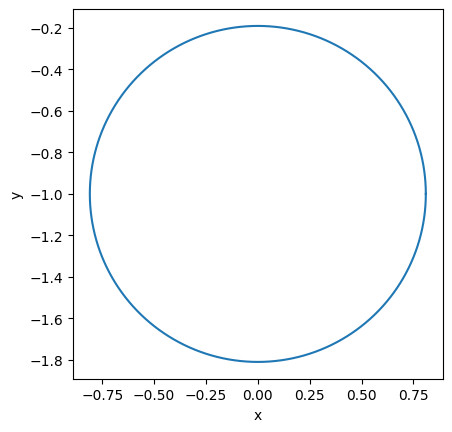

In [9]:
def loop_discretization(R: float, z: float, n: int = 720, offset: float = 0) -> NDArray:
    """ Use Biot-Savart straight line discretization to convert a circular loop centered at (0, offset, z) of radius R into n line segments. 
    
    Parameters
    -----------
    R: float 
        The radius of the loop
    z: float
        The z-coordinate of the loop, where the loop is in the x-y plane
    n: int 
        The number of line segments to break the loop into (default: 720)
    offset: float
        A possible y-shift to the center of the loop

    
    Returns
    --------
        NDArray: An (n+1, 3) array of points, where each pair corresponds to a line segment of the loop
    """
    

    
    # Can adjust as needed to match Mubi's if we determine the arc length method is still applicable. I want to first consider all magnetic effects.
    
    θ, dθ = np.linspace(0, 2*np.pi, n + 1, retstep=True)
    x = R*np.cos(θ)
    y = R*np.sin(θ) + offset
    z = z*np.ones_like(x)
    coil_points = np.array([x, y, z]).transpose()

    return coil_points

cp = loop_discretization(R_main, 1, offset = -1)
plt.plot(cp[:, 0], cp[:, 1], "-")
plt.axis("square")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [63]:
import bfield_calculation
import importlib
importlib.reload(bfield_calculation)

<module 'bfield_calculation' from '/Users/jonah/School/Project8/bfield_calculation.py'>

In [ ]:
from bfield_calculation import bfield, bfield_inputs


def loop_B_numeric(r: NDArray, z0: float, R: float, offset: float = 0, I: float = 1.0, nseg: int = 720) -> tuple:
    """ Computes the effect of a circular current in the x-y plane centered on (0, offset, z0) at the point r

    Parameters
    ----------
    r: NDArray
        An array of the form [x, y, z] to compute the field at
    z0: float
        The z-coordinate of the current loop
    R: float
        The radius of the current loop
    offset: float
        A possible y-shift to the center of the current loop
    I: float
        The current (in A) of the loop (default = 1)
    nseg: int
        The number of line segments to break the loop into (default = 720)

    Returns
    -------
        tuple: 
            (Bx, By, Bz), the x, y, and z components of the magnetic field at r
    """
    grid = np.array(r)
    coil = loop_discretization(R, z0, n = nseg, offset = offset)
    bfield_params = bfield_inputs(coil, grid, currents = np.array([I]))
    field = bfield(bfield_params["coil"], bfield_params["grid"], bfield_params["current"])
    return field[0, 0], field[0, 1], field[0, 2]


def build_M_B(xy_list, z_list, z_coils, R_coils, offset = offset, nseg=720):
    npts = len(xy_list) * len(z_list)  
    n_coils = len(z_coils)

    Mx = np.zeros((npts, n_coils), dtype=float)
    My = np.copy(Mx)
    Mz = np.copy(Mx)

 
 

    row = 0
    for r in xy_list:
      
        for z in z_list:
            for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
                Mx[row, j], My[row, j], Mz[row, j] = loop_B_numeric(np.array([r[0], r[1], z]), zc, Rc, offset=offset[j], I=1.0, nseg=nseg)
            row += 1
    return Mx, My, Mz

In [76]:
build_M_B(xy_list[:10], z_fit[:2], z_coils[:3], R_coils[:3], offset=offset[:3])

(array([[ 0.00000000e+00, -1.03656071e-23, -6.07460762e-24],
        [ 1.52769919e-23,  8.01331218e-25,  1.40620704e-23],
        [ 1.96320121e-09,  2.48969573e-09,  3.19213943e-09],
        [ 1.96319511e-09,  2.48968764e-09,  3.19212858e-09],
        [-7.49876135e-10, -9.50979144e-10, -1.21928875e-09],
        [-7.49873804e-10, -9.50976051e-10, -1.21928461e-09],
        [-2.42665015e-09, -3.07743320e-09, -3.94570141e-09],
        [-2.42664261e-09, -3.07742319e-09, -3.94568799e-09],
        [-7.49876135e-10, -9.50979170e-10, -1.21928883e-09],
        [-7.49873804e-10, -9.50976078e-10, -1.21928468e-09],
        [ 1.96320121e-09,  2.48969578e-09,  3.19213955e-09],
        [ 1.96319511e-09,  2.48968768e-09,  3.19212870e-09],
        [ 4.56173421e-09,  5.77922377e-09,  7.40196418e-09],
        [ 4.56172010e-09,  5.77920505e-09,  7.40193912e-09],
        [ 2.81930679e-09,  3.57175666e-09,  4.57466531e-09],
        [ 2.81929807e-09,  3.57174510e-09,  4.57464981e-09],
        [-9.40917947e-24

In [73]:
def loop_Bz_numeric(r, z_obs, z0, R, I=1.0, nseg=720):
    dtheta = 2*np.pi / nseg
    theta = (np.arange(nseg) + 0.5) * dtheta

    xs = R*np.cos(theta)
    ys = R*np.sin(theta)
    zs = np.full_like(theta, z0)

    dlx = -R*np.sin(theta) * dtheta
    dly =  R*np.cos(theta) * dtheta

    rx = r - xs
    ry = -ys
    rz = z_obs - zs

    r2 = rx*rx + ry*ry + rz*rz
    r3 = r2 * np.sqrt(r2)

    cz = dlx*ry - dly*rx
    return (mu0/(4*np.pi)) * I * np.sum(cz / r3)

M is the response matrix; B = M I where B is the magnetic field vector, M is the response matrix, and I is the current vector

In [12]:
def build_M_Bz(r_list, z_list, z_coils, R_coils, nseg=720):
    npts = len(r_list) * len(z_list)

    M = np.zeros((npts, n_coils), dtype=float)

    row = 0
    for r in r_list:
        for z in z_list:
            for j, (zc, Rc) in enumerate(zip(z_coils, R_coils)):
                M[row, j] = loop_Bz_numeric(r, z, zc, Rc, I=1.0, nseg=nseg)
            row += 1
    return M

Printing M for checks and balances

In [13]:
print("Building M_fit...")
M_fit = build_M_Bz(r_fit, z_fit, z_coils, R_coils, nseg=720)
b_fit = np.full(M_fit.shape[0], B0, dtype=float)

print("M_fit shape:", M_fit.shape)

Building M_fit...
M_fit shape: (12000, 54)


Now we have weighting of the points of evaluation. In this example it is a chebyshev distribution. You can have both radial and longitudinal weighting

In [14]:
def weights_z_sigmoid(z, z0=2.5, alpha=0.1, k=20.0):
    return alpha + (1-alpha)/(1+np.exp(k*(np.abs(z)-z0)))

wz = weights_z_sigmoid(z_fit, z0=2.5, alpha=0.1, k=20.0)

p = 2.0
wr = (r_fit / np.max(r_fit))**p
wr[0] = max(wr[0], 0.2)

w_rows = np.concatenate([np.sqrt(wz) * np.sqrt(wr_i) for wr_i in wr])

A = M_fit * w_rows[:, None]
b = b_fit * w_rows

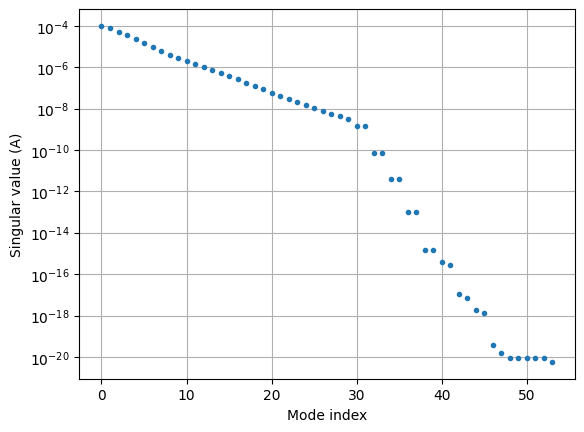

sigma_max: 9.896376267590117e-05


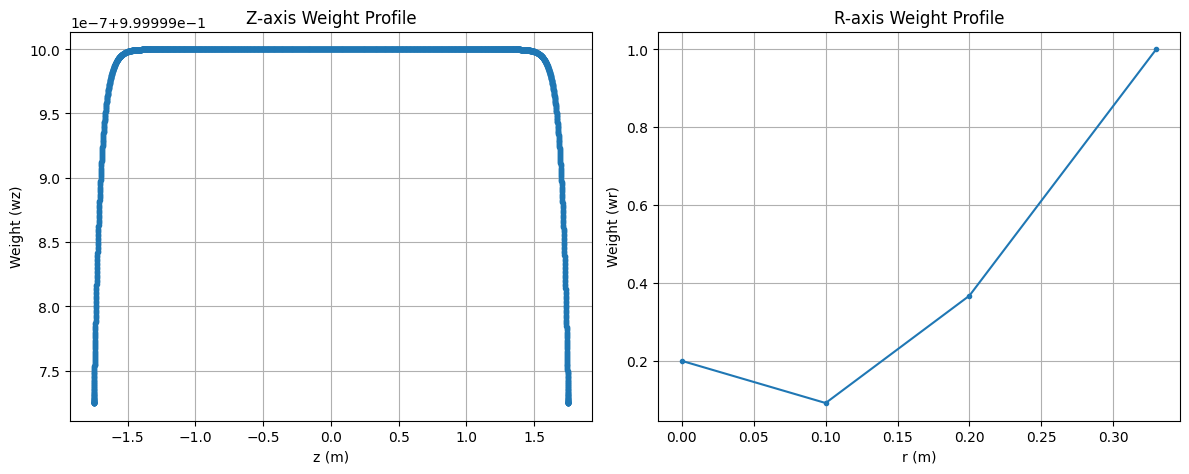

In [15]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)

plt.figure()
plt.semilogy(s, ".")
plt.xlabel("Mode index")
plt.ylabel("Singular value (A)")
plt.grid(True)
plt.show()

sigma_max = s[0]
print("sigma_max:", sigma_max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(z_fit, wz, ".-")
ax1.set_xlabel("z (m)")
ax1.set_ylabel("Weight (wz)")
ax1.set_title("Z-axis Weight Profile")
ax1.grid(True)

ax2.plot(r_fit, wr, ".-")
ax2.set_xlabel("r (m)")
ax2.set_ylabel("Weight (wr)")
ax2.set_title("R-axis Weight Profile")
ax2.grid(True)

plt.tight_layout()
plt.show()

Diff matrix is needed later to visualize the fluctuation of currents

In [16]:
def diff_matrix_second(n):
    D2 = np.zeros((n-2, n), dtype=float)
    for i in range(n-2):
        D2[i, i]     = 1.0
        D2[i, i+1]   = -2.0
        D2[i, i+2]   = 1.0
    return D2

D2 = diff_matrix_second(n_coils)
D2tD2 = D2.T @ D2

def solve_tikhonov_curvature(A, b, lam, eta, D2tD2):
    AtA = A.T @ A
    Atb = A.T @ b
    R = np.eye(A.shape[1]) + (eta**2) * D2tD2
    return np.linalg.solve(AtA + (lam**2) * R, Atb)

In [17]:
print("Building M_ppm")
M_ppm = build_M_Bz(r_ppm, z_ppm, z_coils, R_coils, nseg=720)
b_ppm = np.full(M_ppm.shape[0], B0, dtype=float)
print("M_ppm shape:", M_ppm.shape)

Building M_ppm
M_ppm shape: (11041, 54)


Eta is a parameter that defines how strong the suppresssion of double difference of the currents is. It basically prioritizes the minimization of the fluctuation of the currents

In [18]:
ETA_OVERRIDE = 30

lam_grid = sigma_max * np.logspace(-7, -2, 16)
eta_grid = (
    np.array([ETA_OVERRIDE], dtype=float)
    if ETA_OVERRIDE is not None
    else np.logspace(-2, 2, 13)
)

In [19]:
obj = np.zeros((len(eta_grid), len(lam_grid)), dtype=float)

best = {
    "obj": np.inf,
    "lam": None,
    "eta": None,
    "I": None,
    "max_ppm": None,
    "max_r": None,
    "max_z": None,
}

nz_ppm = len(z_ppm)

for ie, eta in enumerate(eta_grid):
    for il, lam in enumerate(lam_grid):
        I = solve_tikhonov_curvature(A, b, lam, eta, D2tD2)

        B_pred = M_ppm @ I
        ppm = 1e6 * (B_pred - B0) / B0

        idx = int(np.argmax(np.abs(ppm)))
        max_ppm = float(ppm[idx])

        ir = idx // nz_ppm
        iz = idx % nz_ppm
        r_worst = float(r_ppm[ir])
        z_worst = float(z_ppm[iz])

        obj_val = abs(max_ppm)
        obj[ie, il] = obj_val

        if obj_val < best["obj"]:
            best.update({
                "obj": obj_val,
                "lam": float(lam),
                "eta": float(eta),
                "I": I.copy(),
                "max_ppm": max_ppm,
                "max_r": r_worst,
                "max_z": z_worst
            })

print("BEST (min max|ppm| on eval region):")
print("  lambda =", best["lam"])
print("  eta    =", best["eta"])
print("  max ppm =", best["max_ppm"], "at r =", best["max_r"], "m, z =", best["max_z"], "m")

BEST (min max|ppm| on eval region):
  lambda = 9.896376267590117e-12
  eta    = 30.0
  max ppm = -0.057825900838526234 at r = 0.29150000000000004 m, z = 1.7499340996180683 m


Max ppm and the location of that point is printed in the previous block

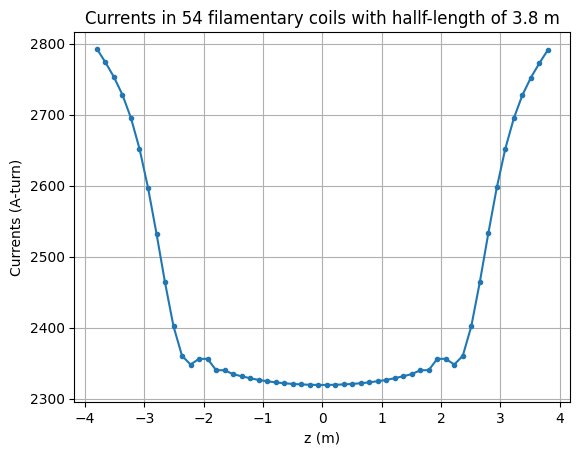

In [20]:
I_sol = best["I"]

plt.figure()
plt.plot(z_coils, I_sol, ".-")
plt.xlabel("z (m)")
plt.ylabel("Currents (A-turn)")
plt.title("Currents in 54 filamentary coils with hallf-length of 3.8 m")
plt.grid(True)
plt.show()

the above block is the plot of currents in A-turns with the z position.

In [21]:
z_eval = chebyshev_nodes(2000, z_min, z_max)
r_plot = [0.0, 0.1, 0.2, 0.33]

def Bz_total_from_I(r, zlist, I_vec):
    out = np.zeros_like(zlist, dtype=float)
    for i, z in enumerate(zlist):
        out[i] = sum(
            loop_Bz_numeric(r, z, zc, Rc, Ij)
            for Ij, zc, Rc in zip(I_vec, z_coils, R_coils)
        )
    return out

In [22]:
z_eval = chebyshev_nodes(2000, z_min, z_max)
r_plot = [0.0, 0.1, 0.2, 0.33]

fig = go.Figure()

for r in r_plot:
    fig.add_trace(go.Scatter(
        x=z_eval,
        y=Bz_total_from_I(r, z_eval, I_sol),
        mode="lines",
        name=f"r={r} m"
    ))

fig.add_trace(go.Scatter(
    x=z_eval,
    y=np.full_like(z_eval, B0),
    mode="lines",
    name="B0",
    line=dict(dash="dash")
))

fig.update_layout(
    title="zoomed-in",
    xaxis_title="z (m)",
    yaxis_title="Bz (T)",
    hovermode="x unified"
)

fig.show()

the above block is just the interactive plot

In [23]:
z_slices = np.array([0.00, 0.10, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.60, 1.65, 1.70, 1.75], dtype=float)
r_vals = np.linspace(0.0, 0.33, 61)

fig = go.Figure()

for z0 in z_slices:
    Bz_r = np.array([Bz_total_from_I(r, np.array([z0]), I_sol)[0] for r in r_vals])
    ppm_r = 1e6 * (Bz_r - B0) / B0

    fig.add_trace(go.Scatter(
        x=1e3 * r_vals,
        y=ppm_r,
        mode="lines",
        name=f"z={z0:.2f} m"
    ))

fig.update_layout(
    title="PPM vs radius at different z slices with worst ~0.06 ppm at z = 1.75 m and r = 0.29 m",
    xaxis_title="Radius r (mm)",
    yaxis_title="ΔB / B₀ (ppm)",
    hovermode="x unified"
)

fig.show()

And the above is just the ppm vs radius vs z slice so we can see what ppm is at what point in the target volume

In [24]:
print("Per-slice worst ppm over r:")
print("----------------------------------------------------------")

global_best = {"absppm": -1.0, "ppm": None, "r": None, "z": None}

for z0 in z_slices:
    Bz_r = np.array([Bz_total_from_I(r, np.array([z0]), I_sol)[0] for r in r_vals])
    ppm_r = 1e6 * (Bz_r - B0) / B0

    idx = int(np.argmax(np.abs(ppm_r)))
    worst_ppm = float(ppm_r[idx])
    worst_r   = float(r_vals[idx])

    print(f"z={z0:7.5f} m : max |ppm| = {worst_ppm:10.5f} ppm at r={worst_r:.4f} m")

    if abs(worst_ppm) > global_best["absppm"]:
        global_best.update({"absppm": abs(worst_ppm), "ppm": worst_ppm, "r": worst_r, "z": float(z0)})

print("----------------------------------------------------------")
print(f"GLOBAL worst across these slices: {global_best['ppm']:.5f} ppm at r={global_best['r']:.4f} m, z={global_best['z']:.3f} m")

Per-slice worst ppm over r:
----------------------------------------------------------
z=0.00000 m : max |ppm| =   -0.00052 ppm at r=0.3300 m
z=0.10000 m : max |ppm| =    0.00011 ppm at r=0.3300 m
z=0.25000 m : max |ppm| =    0.00032 ppm at r=0.3300 m
z=0.50000 m : max |ppm| =    0.00047 ppm at r=0.3300 m
z=0.75000 m : max |ppm| =   -0.00181 ppm at r=0.3300 m
z=1.00000 m : max |ppm| =   -0.00241 ppm at r=0.3300 m
z=1.25000 m : max |ppm| =    0.00215 ppm at r=0.3300 m
z=1.50000 m : max |ppm| =    0.00848 ppm at r=0.3300 m
z=1.60000 m : max |ppm| =   -0.01083 ppm at r=0.3300 m
z=1.65000 m : max |ppm| =   -0.00599 ppm at r=0.2695 m
z=1.70000 m : max |ppm| =   -0.01419 ppm at r=0.2695 m
z=1.75000 m : max |ppm| =   -0.05794 ppm at r=0.2915 m
----------------------------------------------------------
GLOBAL worst across these slices: -0.05794 ppm at r=0.2915 m, z=1.750 m


In [25]:
print("\nCoil current vector")
print("-----------------------------------------------------------------------")
print(" idx |      z (m) |   R (m) |     I (A-turn)")
print("-----------------------------------------------------------------------")

for j, (zc, Rc, Ij) in enumerate(zip(z_coils, R_coils, I_sol)):
    print(f"{j:4d} | {zc:9.4f} | {Rc:7.4f} | {Ij:12.6f}")

print("-----------------------------------------------------------------------")
print(f"Total coils listed: {len(I_sol)}")


Coil current vector
-----------------------------------------------------------------------
 idx |      z (m) |   R (m) |     I (A-turn)
-----------------------------------------------------------------------
   0 |   -3.8000 |  0.8100 |  2792.493780
   1 |   -3.6566 |  0.8100 |  2773.482290
   2 |   -3.5132 |  0.8100 |  2752.842046
   3 |   -3.3698 |  0.8100 |  2727.815508
   4 |   -3.2264 |  0.8100 |  2695.164778
   5 |   -3.0830 |  0.8100 |  2652.047858
   6 |   -2.9396 |  0.8100 |  2597.242619
   7 |   -2.7962 |  0.8100 |  2532.450901
   8 |   -2.6528 |  0.8100 |  2463.719504
   9 |   -2.5094 |  0.8100 |  2401.878461
  10 |   -2.3660 |  0.8100 |  2360.458579
  11 |   -2.2226 |  0.8100 |  2348.212693
  12 |   -2.0792 |  0.8100 |  2356.165600
  13 |   -1.9358 |  0.8100 |  2356.186966
  14 |   -1.7925 |  0.8100 |  2340.293725
  15 |   -1.6491 |  0.8100 |  2340.043888
  16 |   -1.5057 |  0.8100 |  2334.724407
  17 |   -1.3623 |  0.8100 |  2331.622873
  18 |   -1.2189 |  0.8100 |  2328

In [26]:
coil_table = np.column_stack([np.arange(len(I_sol)), z_coils, R_coils, I_sol])
np.savetxt(
    "coil_currents_table.csv",
    coil_table,
    delimiter=",",
    header="index,z_m,R_m,I_Aturn",
    comments=""
)
print("Saved: coil_currents_table.csv")

Saved: coil_currents_table.csv


And lastly we can print the solution i.e the current vector and export it if needed